# Synthesizability Score Distributions & Correlation

Deduplicated per unique SMILES (scores are per-molecule; the CSV has one row per assay, so the same
molecule can repeat up to 43x). Compares `llm_score` against the baseline scorers: SA, SCScore,
RAscore, SYBA, GASA, FSscore.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sns.set_theme(style="whitegrid")

SCORE_COLS = [
    "llm_score", "sa_score", "sc_score", "ra_score",
    "syba_score", "gasa_es_prob", "fs_score",
]

In [2]:
df = pd.read_csv(_PROJECT_ROOT / "tack_v2_with_predictions_scores_splits.csv")
df_unique = df.drop_duplicates(subset="SMILES")[["SMILES", *SCORE_COLS]]
df_unique = df[df['PROTAC-Splitter_Number_of_Warnings'] == 0]

print(f"Rows: {len(df)} -> unique SMILES: {len(df_unique)}")
df_unique.describe()

Rows: 6214 -> unique SMILES: 1825


,DC50,DC50_h,DC50_Range_Min,DC50_Range_Max,Dmax,Dmax_h,Dmax_Range_Min,Dmax_Range_Max,Dmax_conc,Dmax_conc_Range_Min,...,sa_score_scaled,sc_score,sc_score_scaled,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled
count,1667.000000,782.000000,67.000000,67.000000,853.000000,502.000000,26.000000,26.000000,79.000000,0.0,...,1825.000000,1825.000000,1.825000e+03,1825.000000,1825.000000,1.825000e+03,1825.000000,1825.000000,1825.000000,1825.000000
mean,969.349634,17.858696,58.029851,671.162687,77.031161,18.032869,59.953846,79.661538,417.088608,NaN,...,0.593896,4.988390,2.902584e-03,0.484584,130.655419,9.899005e-01,0.255342,0.718878,-29.277384,0.053688
std,4852.678374,12.623146,197.092063,469.674354,23.859707,12.106621,14.889519,8.233496,1320.667956,NaN,...,0.082161,0.048842,1.221060e-02,0.258549,62.574596,9.876766e-02,0.436173,0.297434,3.628808,0.019675
min,0.010000,0.250000,1.000000,3.000000,-10.500000,2.500000,36.000000,64.000000,5.000000,NaN,...,0.235615,4.466662,0.000000e+00,0.016547,-117.120313,1.365509e-51,0.000000,0.000124,-41.156250,0.016054
25%,3.850000,6.000000,10.000000,75.750000,65.000000,6.000000,50.000000,75.000000,10.000000,NaN,...,0.556230,4.999841,2.020121e-09,0.280348,88.571353,1.000000e+00,0.000000,0.479818,-31.218750,0.042214
50%,16.700000,16.000000,10.000000,1000.000000,86.000000,24.000000,50.000000,75.000000,100.000000,NaN,...,0.608926,4.999999,1.984799e-07,0.475960,130.501312,1.000000e+00,0.000000,0.863031,-29.093750,0.051692
75%,161.950000,24.000000,10.000000,1000.000000,95.000000,24.000000,70.750000,85.000000,200.000000,NaN,...,0.647086,5.000000,3.974365e-05,0.711583,160.129637,1.000000e+00,1.000000,0.943920,-26.953125,0.063251
max,100000.000000,96.000000,1487.000000,1994.500000,106.000000,96.000000,93.000000,97.500000,10000.000000,NaN,...,0.784130,5.000000,1.333345e-01,0.980548,327.792584,1.000000e+00,1.000000,0.998324,-13.164062,0.211417


## Score distributions

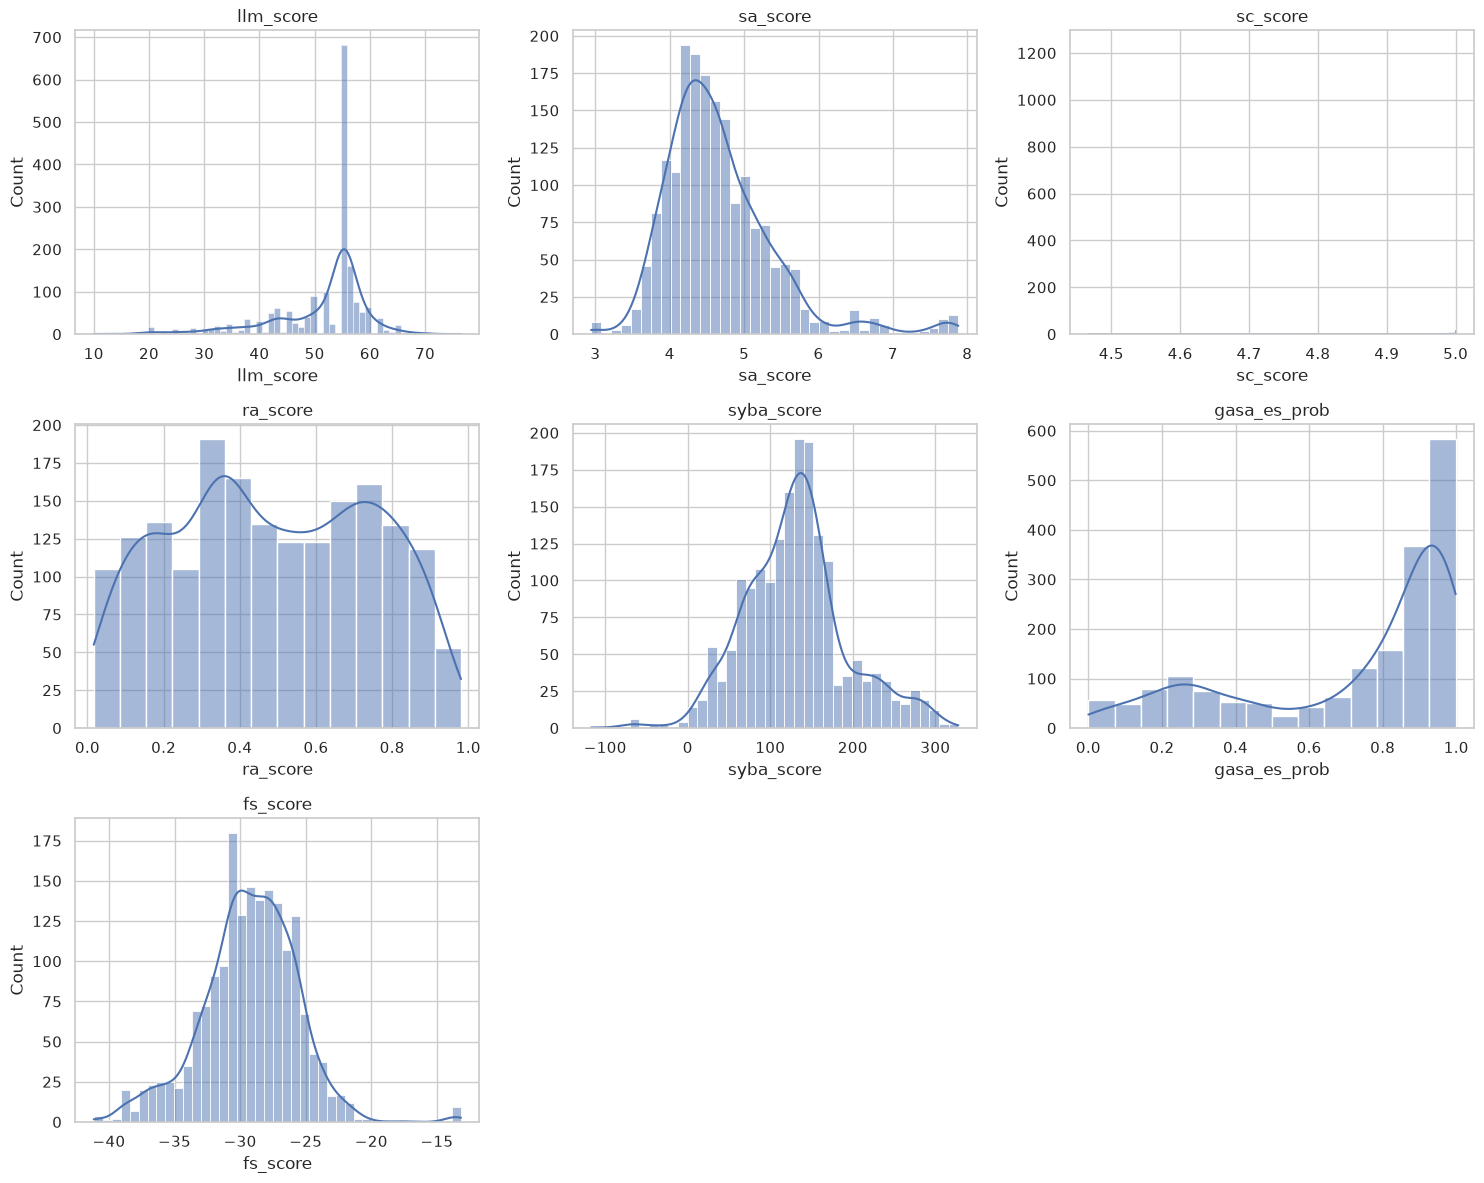

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, SCORE_COLS):
    sns.histplot(df_unique[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(SCORE_COLS):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

## Correlation analysis

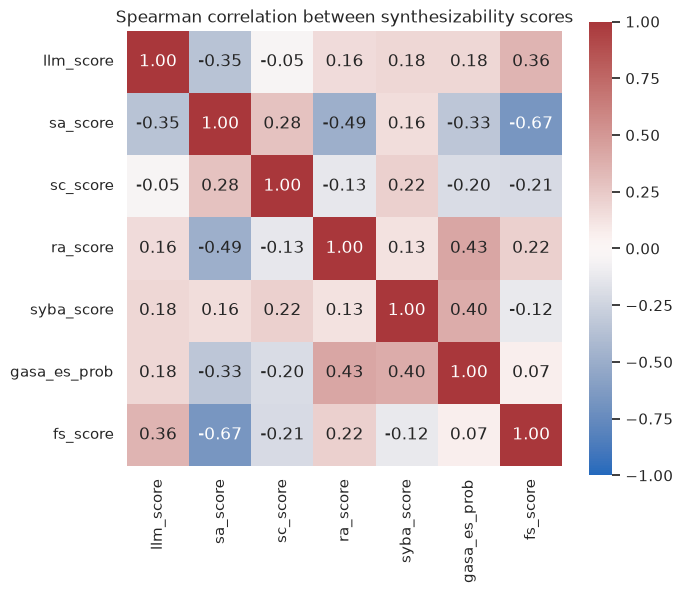

In [4]:
corr = df_unique[SCORE_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Spearman correlation between synthesizability scores")
fig.tight_layout()
plt.show()

In [ ]:
sns.pairplot(df_unique[SCORE_COLS].dropna(), diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.show()

In [ ]:
df['PROTAC-Splitter_Warnings'].value_counts()

In [ ]:
from rdkit import Chem

for smiles in df['SMILES']:
    display(Chem.MolFromSmiles(smiles))

KeyboardInterrupt: 